## Coverage calculations

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math
import sourmash
import collections

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

## Do genes correlate with each other when they are from the same species?

tl;dr many do

In [3]:
gene_df = pl.read_parquet('../inputs.abundhist/mapping-coverage.parquet')
gene_df

metag,species,gene,len,hits,breadth,depth_all,depth_cov,anchor,description
str,str,str,i64,i64,f64,f64,f64,i64,str
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""LJHBCGLM_01294""",393,0,0.0,0.0,NaN,0,"""BLAST match to isolate genome"""
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""DKAPMIEG_00121""",564,127,0.225177,0.381206,1.692913,1,"""BLAST match to isolate genome"""
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""FMBBPIHC_01435""",522,91,0.17433,0.17433,1.0,0,"""BLAST match to isolate genome"""
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""IEPMJGAI_00771""",420,115,0.27381,0.27381,1.0,0,"""BLAST match to isolate genome"""
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""EBLLCBKE_00022""",459,91,0.198257,0.198257,1.0,0,"""BLAST match to isolate genome"""
…,…,…,…,…,…,…,…,…,…
"""ERR8314743""","""s__Lactobacillus amylovorus""","""OBGMJDLM_01221""",2574,2574,1.0,12.188034,12.188034,0,"""BLAST match to calcium-translo…"
"""ERR8314743""","""s__Lactobacillus amylovorus""","""OMBJBIHD_01711""",1134,1121,0.988536,6.604938,6.681534,1,"""BLAST match to LD-transpeptida…"
"""SRR12795793""","""s__Bariatricus sp004560705""","""CHOLCMOC_00863""",1386,1194,0.861472,1.837662,2.133166,0,"""BLAST match to BREX system Lon…"


found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


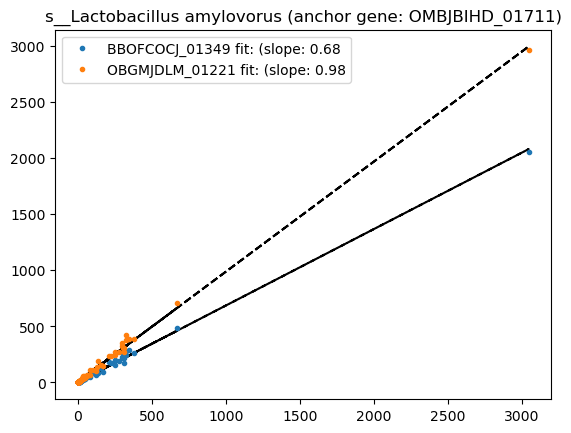

In [4]:
def plot_genes_correlation(df, species):
    xx_df = df.filter(pl.col("species") == species).drop_nans()

    genes = list(sorted(xx_df['gene'].unique().to_list()))

    # is an anchor gene set?
    if len(xx_df.filter(pl.col("anchor") == 1)):
        agene_list = xx_df.filter(pl.col("anchor") == 1)['gene'].unique().to_list()
        assert len(agene_list) == 1, agene_list
        anchor_gene = agene_list[0]
        genes.remove(anchor_gene)
        print(f"found defined anchor gene {anchor_gene} for {species}")
    else:
        anchor_gene = genes.pop()

    anchor_df = xx_df.filter(pl.col('gene') == anchor_gene).with_columns(
        pl.col('depth_all').alias("anchor_depth")
    )

    for gene in genes:
        this_df = xx_df.filter(pl.col('gene') == gene).with_columns(
            pl.col('depth_all').alias("this_depth")
        )
        yy_df = this_df.join(anchor_df, on='metag', how='inner')
        x = yy_df['anchor_depth'].to_list()
        y = yy_df['this_depth'].to_list()
        coef = np.polyfit(x, y, 1)
        poly1d_fn = np.poly1d(coef) 
        plt.plot(x, poly1d_fn(x), '--k')

        plt.plot(x, y, '.', label=f"{gene} fit: (slope: {coef[0]:.2f}")

    plt.title(f'{species} (anchor gene: {anchor_gene})')
    #plt.xlim(0, 500)
    #plt.ylim(0, 500)
    plt.legend(loc='upper left')

plot_genes_correlation(gene_df, 's__Lactobacillus amylovorus')

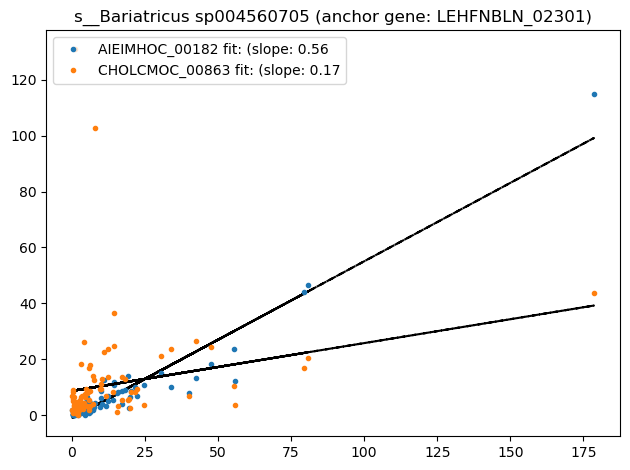

found defined anchor gene OIGHMFGK_00345 for s__Cryptobacteroides sp900546925


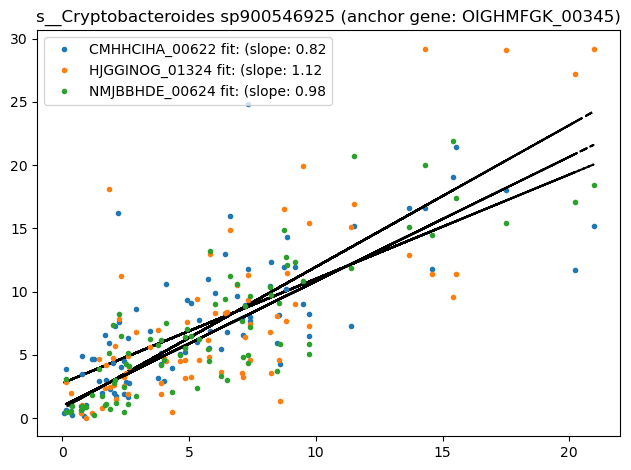

/tmp/ipykernel_100618/3317133214.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


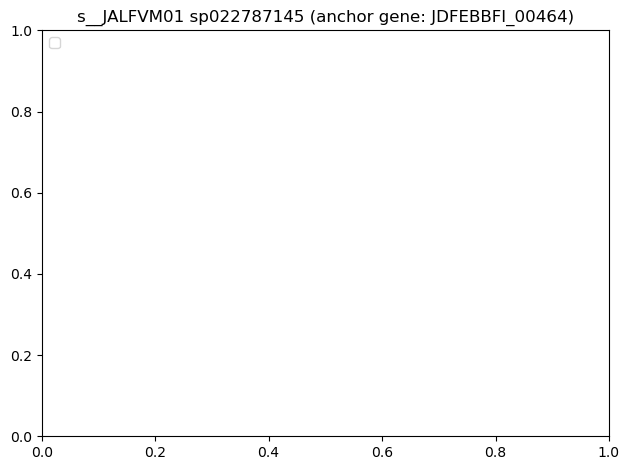

found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


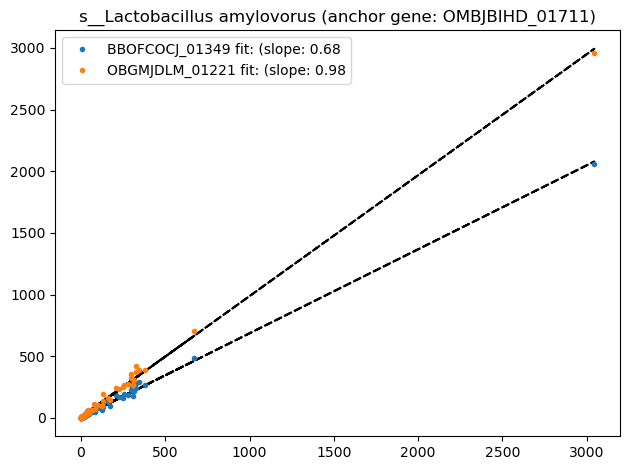

found defined anchor gene DKAPMIEG_00121 for s__Mogibacterium_A kristiansenii


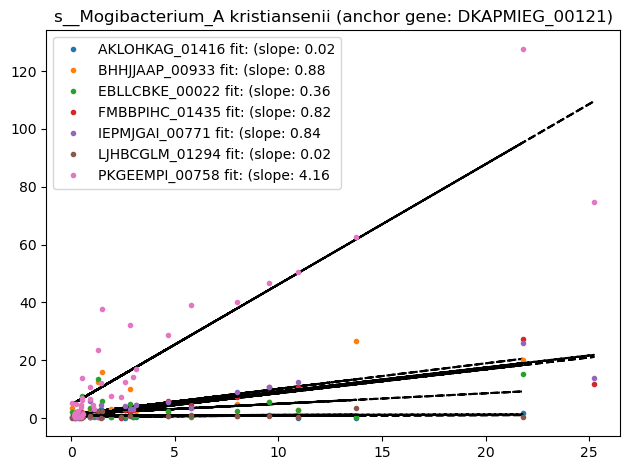

found defined anchor gene CNENGHLA_01260 for s__Phascolarctobacterium_A succinatutens


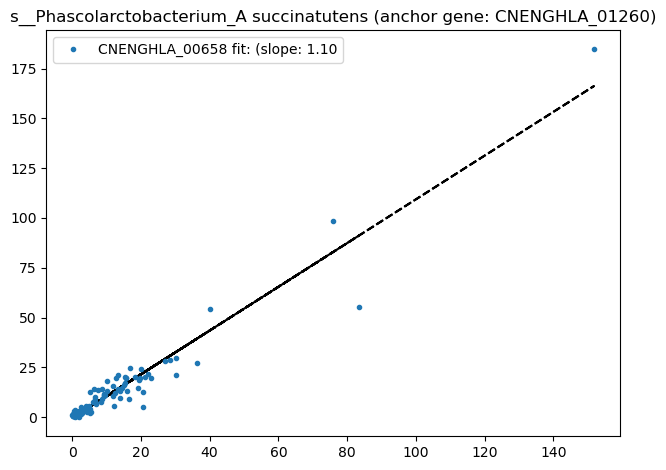

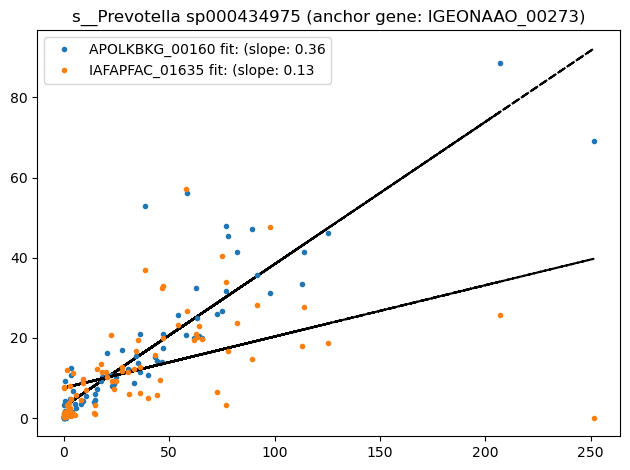

found defined anchor gene GFALEAHI_01277 for s__Prevotella sp002251295


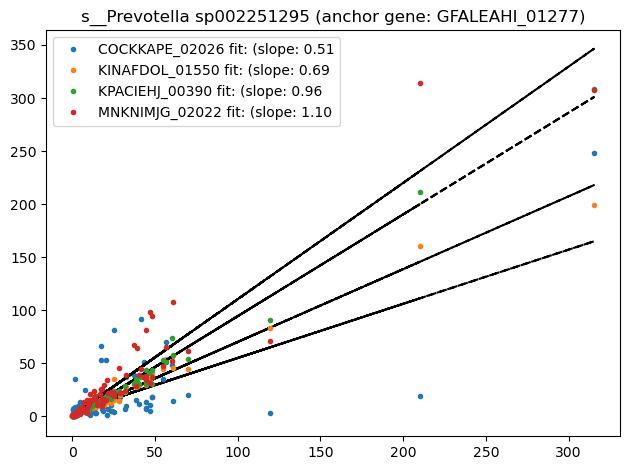

found defined anchor gene NLNOELNI_01902 for s__Sodaliphilus sp004557565


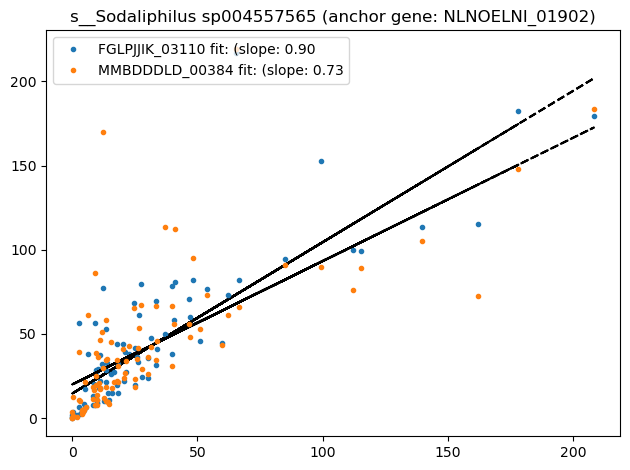

In [5]:
for species in sorted(gene_df['species'].unique()):
    plot_genes_correlation(gene_df, species)
    plt.tight_layout()
    plt.show()

found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


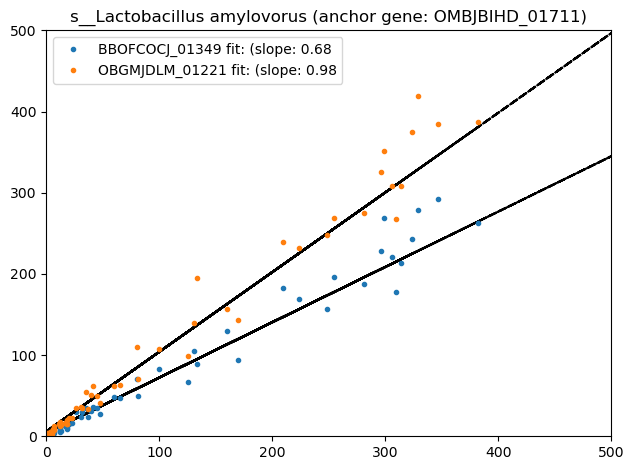

In [6]:
species = 's__Lactobacillus amylovorus'
plot_genes_correlation(gene_df, species)
plt.tight_layout()
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.show()

In [7]:
gene_avg_df = gene_df.group_by(["metag", "species"]).agg(
    pl.col("depth_all").mean(),
    pl.col("depth_cov").mean(),
)
gene_avg_df

metag,species,depth_all,depth_cov
str,str,f64,f64
"""ERR3211974""","""s__Phascolarctobacterium_A suc…",2.249846,3.107175
"""SRR11805643""","""s__Cryptobacteroides sp9005469…",3.390731,3.537215
"""ERR3211929""","""s__Cryptobacteroides sp9005469…",4.744635,4.783371
"""SRR12795790""","""s__Sodaliphilus sp004557565""",0.0,NaN
"""ERR1135303""","""s__Cryptobacteroides sp9005469…",5.976687,6.072729
…,…,…,…
"""SRR11183981""","""s__Mogibacterium_A kristiansen…",11.3026,12.235504
"""ERR8314767""","""s__Mogibacterium_A kristiansen…",0.166041,NaN
"""ERR1135303""","""s__Prevotella sp000434975""",22.751282,23.063549


## Can we correlate k-mer coverage with coverage from gene mapping?

Basically, yes!

Here we are evaluating our k-mer collector's curves of coverage (y axis) against mapping based coverage using the species-specific genes. If we get straight lines (and we do!) then we win!

I'm not entirely sure why the slopes vary tho. Working on it.

In [8]:
kmer_df = pl.read_parquet('../inputs.abundhist/kmer-coverage.parquet')

In [9]:
join2_df = kmer_df.with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    pl.col("depth").alias("depth_est"),
).select(["species", "metag", "depth_est"])
join2_df

species,metag,depth_est
str,str,f64
"""s__Prevotella sp002251295""","""SRR11126108""",0.61196
"""s__UMGS1225 sp034086705""","""SRR11126108""",0.02387
"""s__Mogibacterium_A kristiansen…","""SRR11126108""",1.870446
"""s__JAFBIX01 sp021531895""","""SRR11126108""",0.210593
"""s__Phascolarctobacterium_A suc…","""SRR11126108""",2.619687
…,…,…
"""s__Roseburia inulinivorans""","""ERR8314759""",1.195389
"""s__CAG-269 sp014846485""","""ERR8314759""",0.026461
"""s__Phascolarctobacterium_A suc…","""ERR8314759""",1.211618


## Compare mean gene expression with estimates

In [10]:
combo_df = join2_df.join(gene_avg_df, on=["species", "metag"], how="inner")
combo_df

species,metag,depth_est,depth_all,depth_cov
str,str,f64,f64,f64
"""s__Prevotella sp002251295""","""SRR14812372""",6.170925,11.334461,12.056659
"""s__Mogibacterium_A kristiansen…","""SRR14812372""",5.462044,3.442203,4.248076
"""s__Phascolarctobacterium_A suc…","""SRR14812372""",4.620836,10.416681,10.729679
"""s__Sodaliphilus sp004557565""","""SRR14812372""",5.174016,21.728208,22.114788
"""s__JALFVM01 sp022787145""","""SRR14812372""",0.211759,0.692506,2.0
…,…,…,…,…
"""s__JALFVM01 sp022787145""","""SRR17241596""",0.585868,1.651163,1.930514
"""s__Bariatricus sp004560705""","""SRR17241596""",5.27492,9.858619,10.785189
"""s__Cryptobacteroides sp9005469…","""SRR17241596""",1.429369,1.926641,4.391577


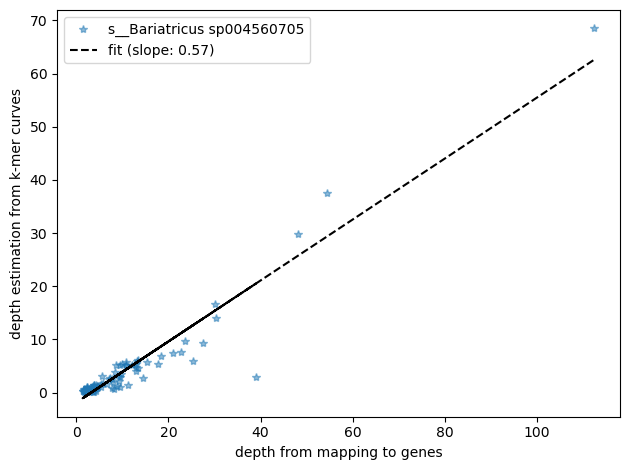

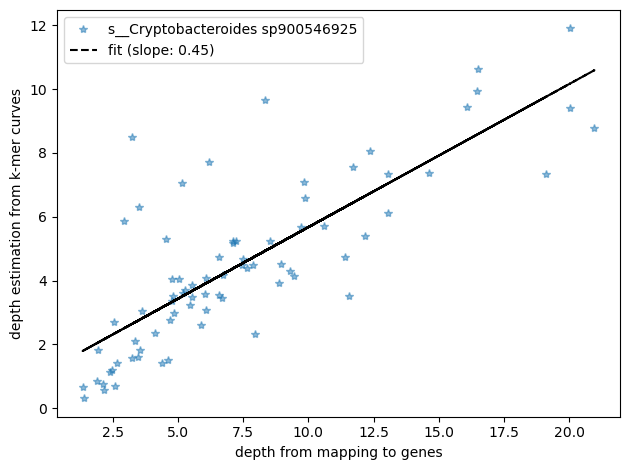

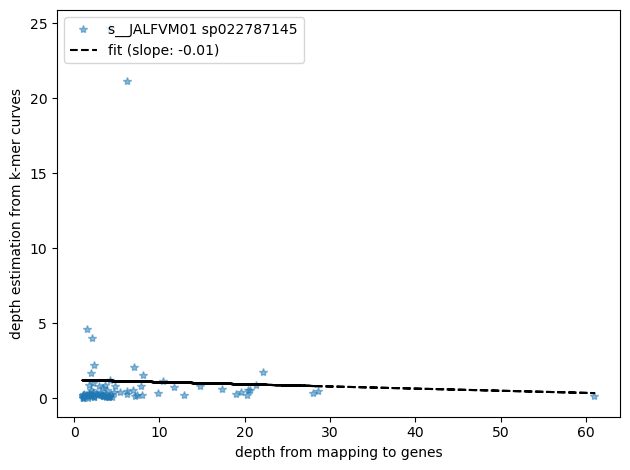

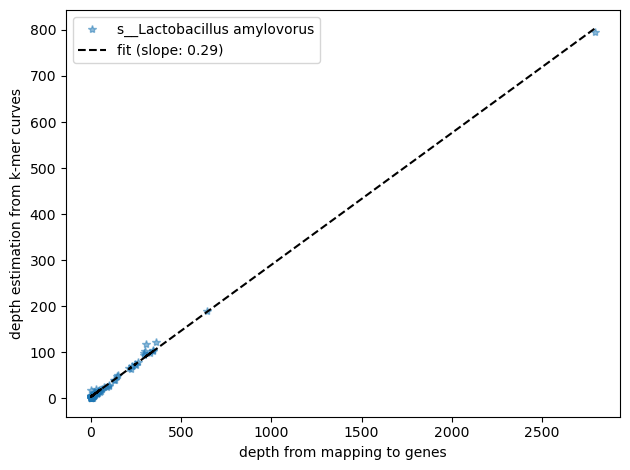

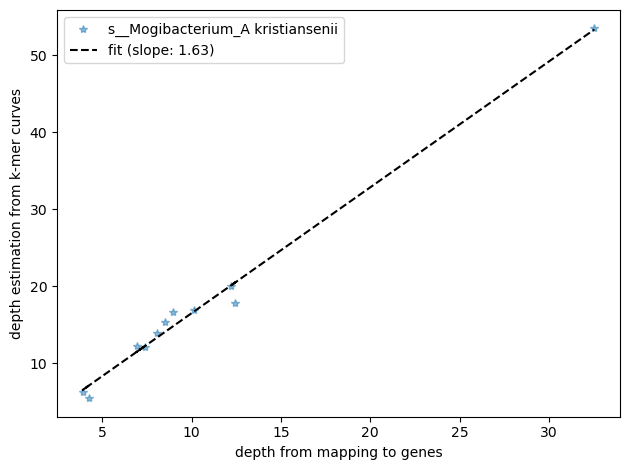

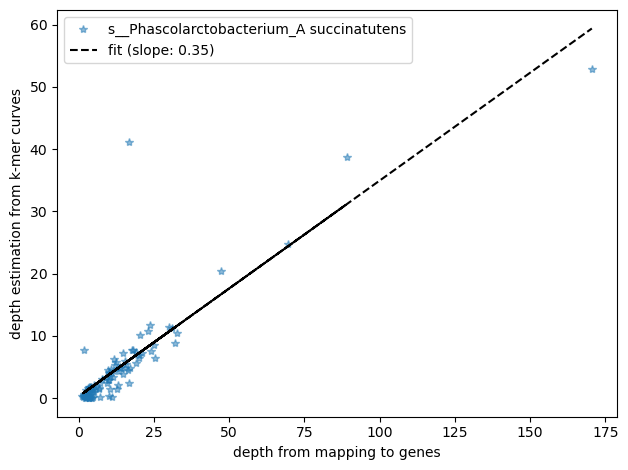

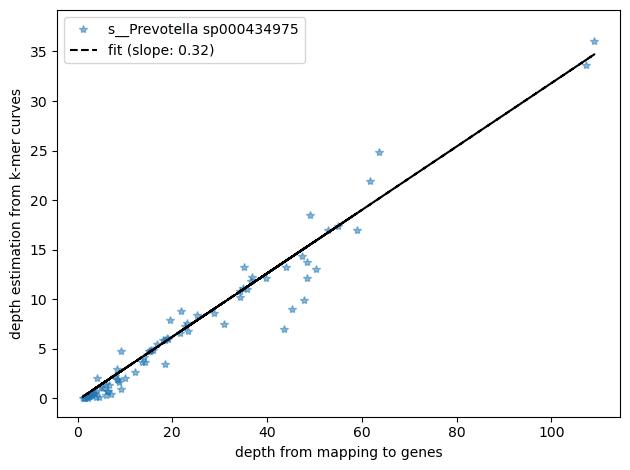

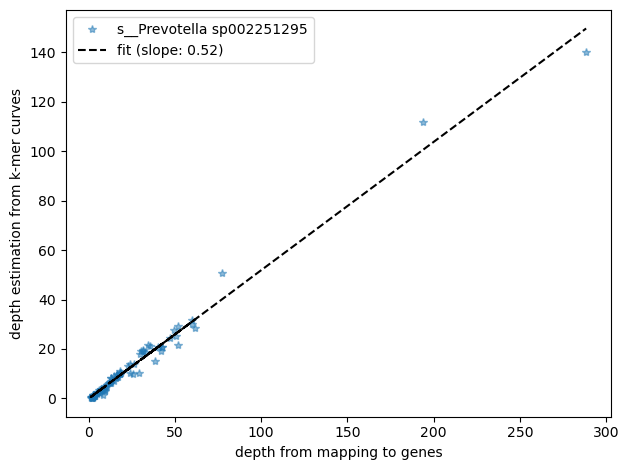

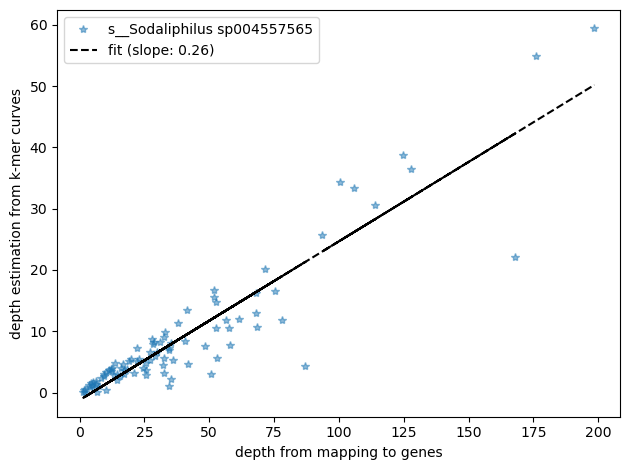

In [11]:
for species in sorted(combo_df['species'].unique()):
    xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
    q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
    xx2_df = xx_df.filter(
        pl.col("depth_est") < q95
    )
    x = xx_df['depth_cov']
    y = xx_df['depth_est']
    plt.plot(x, y, '*', alpha=0.5, label=species)

    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')
    
    #plt.xlim(0, 600)
    #plt.ylim(0, 200)
    plt.xlabel('depth from mapping to genes')
    plt.ylabel('depth estimation from k-mer curves')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

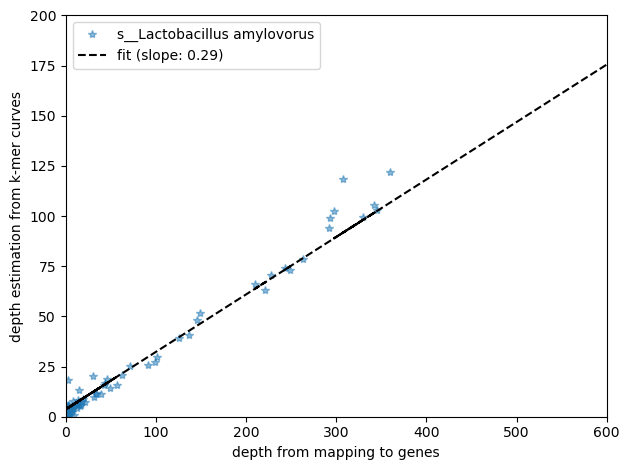

In [12]:
species = "s__Lactobacillus amylovorus"

xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
xx2_df = xx_df.filter(
    pl.col("depth_est") < q95
)
x = xx_df['depth_cov']
y = xx_df['depth_est']
plt.plot(x, y, '*', alpha=0.5, label=species)

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

plt.xlim(0, 600)
plt.ylim(0, 200)
plt.xlabel('depth from mapping to genes')
plt.ylabel('depth estimation from k-mer curves')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Compare k-mer coverage estimates with anchor genes only

In [13]:
anchor_gene_df = gene_df.filter(pl.col("anchor") == 1)
combo2_df = join2_df.join(anchor_gene_df, on=["species", "metag"], how="inner")
combo2_df

species,metag,depth_est,gene,len,hits,breadth,depth_all,depth_cov,anchor,description
str,str,f64,str,i64,i64,f64,f64,f64,i64,str
"""s__Prevotella sp002251295""","""SRR14812372""",6.170925,"""GFALEAHI_01277""",2526,2499,0.989311,13.761679,13.910364,1,"""YfnO"""
"""s__Mogibacterium_A kristiansen…","""SRR14812372""",5.462044,"""DKAPMIEG_00121""",564,318,0.56383,0.920213,1.632075,1,"""BLAST match to isolate genome"""
"""s__Phascolarctobacterium_A suc…","""SRR14812372""",4.620836,"""CNENGHLA_01260""",1398,1312,0.938484,9.550072,10.176067,1,"""BLAST match to hydrogenase lar…"
"""s__Sodaliphilus sp004557565""","""SRR14812372""",5.174016,"""NLNOELNI_01902""",1968,1844,0.936992,16.70935,17.832972,1,"""IG-like domain-containing prot…"
"""s__Lactobacillus amylovorus""","""SRR14812372""",102.806038,"""OMBJBIHD_01711""",1134,1129,0.995591,382.226631,383.919398,1,"""BLAST match to LD-transpeptida…"
…,…,…,…,…,…,…,…,…,…,…
"""s__Mogibacterium_A kristiansen…","""SRR17241596""",0.509734,"""DKAPMIEG_00121""",564,0,0.0,0.0,NaN,1,"""BLAST match to isolate genome"""
"""s__Phascolarctobacterium_A suc…","""SRR17241596""",0.22823,"""CNENGHLA_01260""",1398,328,0.234621,0.751073,3.20122,1,"""BLAST match to hydrogenase lar…"
"""s__Sodaliphilus sp004557565""","""SRR17241596""",0.352896,"""NLNOELNI_01902""",1968,207,0.105183,0.442073,4.202899,1,"""IG-like domain-containing prot…"


In [14]:
combo2_df['species'].unique().to_list()

['s__Cryptobacteroides sp900546925',
 's__Prevotella sp002251295',
 's__Phascolarctobacterium_A succinatutens',
 's__Lactobacillus amylovorus',
 's__Sodaliphilus sp004557565',
 's__Mogibacterium_A kristiansenii']

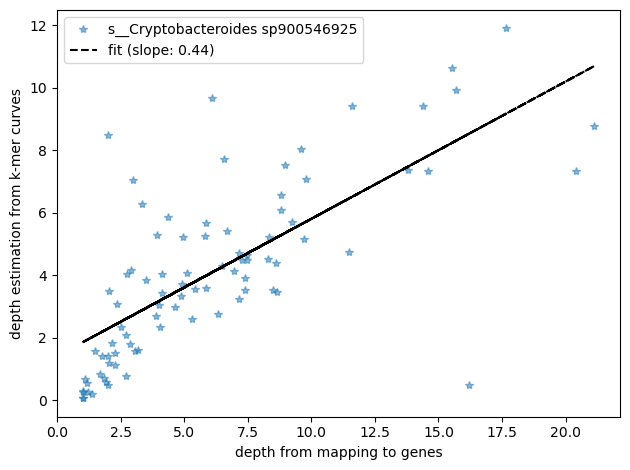

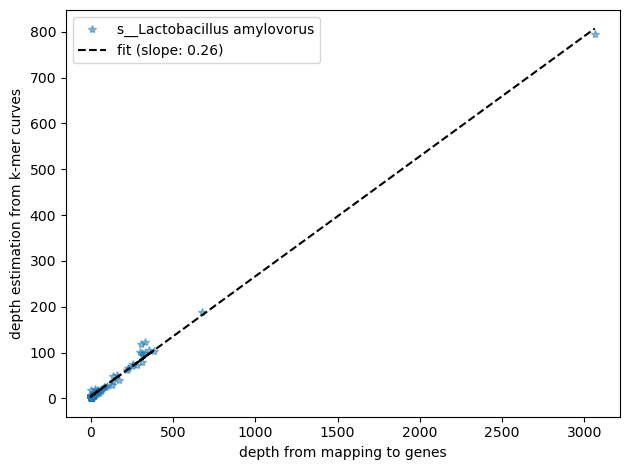

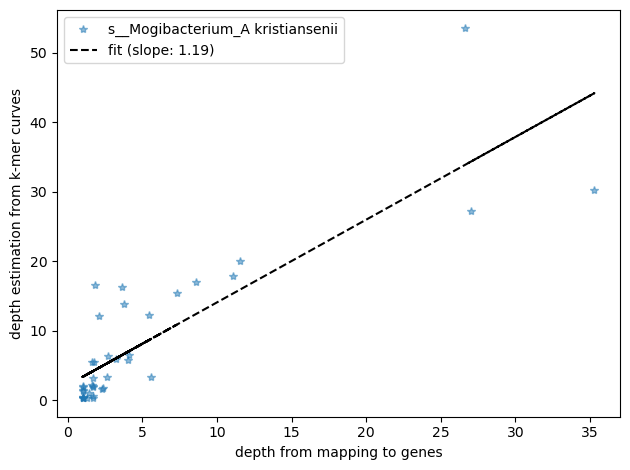

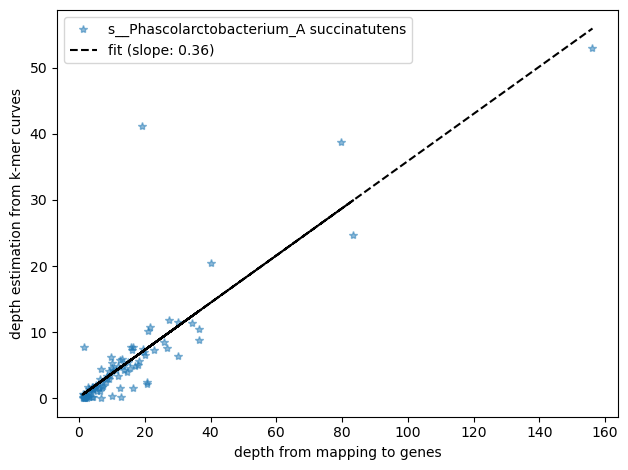

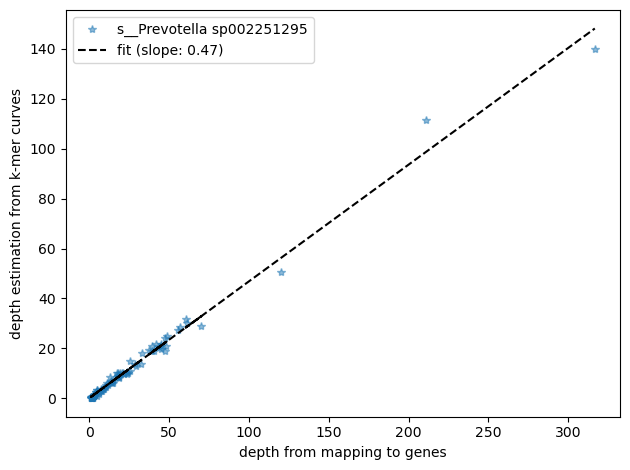

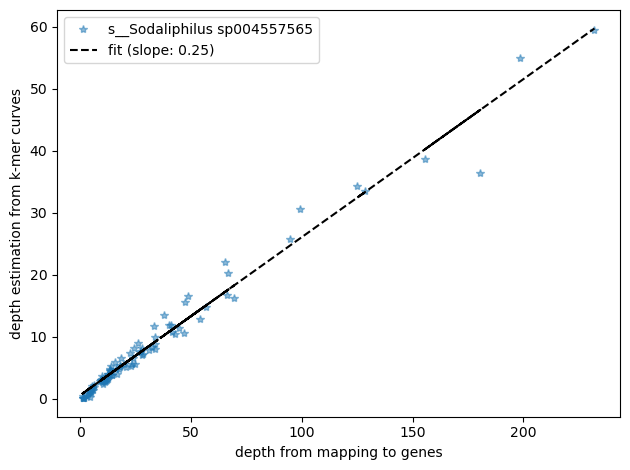

In [15]:
for species in sorted(combo2_df['species'].unique()):
    xx_df = combo2_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
    q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
    xx2_df = xx_df.filter(
        pl.col("depth_est") < q95
    )
    x = xx_df['depth_cov']
    y = xx_df['depth_est']
    plt.plot(x, y, '*', alpha=0.5, label=species)

    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')
    
    #plt.xlim(0, 600)
    #plt.ylim(0, 200)
    plt.xlabel('depth from mapping to genes')
    plt.ylabel('depth estimation from k-mer curves')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

## Extract some specific metagenomes...

In [16]:
combo_df.filter(pl.col('species') == 's__Lactobacillus amylovorus').sort(by='depth_est').tail()['metag'].to_list()

['SRR8960379', 'SRR8960968', 'SRR12795775', 'SRR10209683', 'SRR17241521']

In [17]:
SS = 's__Prevotella sp000434975'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌───────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                   ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                       ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                       ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═══════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Prevotella sp000434975 ┆ SRR8960379  ┆ 0.276206  ┆ 0.648068  ┆ 2.223566  │
│ s__Prevotella sp000434975 ┆ SRR8960101  ┆ 0.520331  ┆ 1.685741  ┆ 2.953547  │
│ s__Prevotella sp000434975 ┆ SRR14812375 ┆ 1.17055   ┆ 4.649192  ┆ 4.94727   │
│ s__Prevotella sp000434975 ┆ ERR3211876  ┆ 5.937255  ┆ 16.978302 ┆ 17.93471  │
│ s__Prevotella sp000434975 ┆ SRR14812372 ┆ 6.639899  ┆ 21.34831  ┆ 21.678141 │
│ s__Prevotella sp000434975 ┆ ERR1135303  ┆ 7.592144  ┆ 22.751282 ┆ 23.063549 │
│ s__Prevotella sp000434975 ┆ SRR11489769 ┆ 9.9575    ┆ 47.09905  ┆ 47.718005 │
│ s__Prevotella sp0004349

['SRR8960379',
 'SRR8960101',
 'SRR14812375',
 'ERR3211876',
 'SRR14812372',
 'ERR1135303',
 'SRR11489769',
 'ERR3211839',
 'ERR8314767',
 'ERR1135349']

In [18]:
SS = 's__Lactobacillus amylovorus'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────┬─────────────┬────────────┬────────────┬────────────┐
│ species                     ┆ metag       ┆ depth_est  ┆ depth_all  ┆ depth_cov  │
│ ---                         ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│ str                         ┆ str         ┆ f64        ┆ f64        ┆ f64        │
╞═════════════════════════════╪═════════════╪════════════╪════════════╪════════════╡
│ s__Lactobacillus amylovorus ┆ ERR3211783  ┆ 1.666277   ┆ 0.53834    ┆ 1.23021    │
│ s__Lactobacillus amylovorus ┆ ERR8314733  ┆ 2.510235   ┆ 2.964572   ┆ 3.590919   │
│ s__Lactobacillus amylovorus ┆ ERR8314788  ┆ 3.722073   ┆ 5.806884   ┆ 6.26126    │
│ s__Lactobacillus amylovorus ┆ ERR1135238  ┆ 8.27999    ┆ 12.781252  ┆ 13.640336  │
│ s__Lactobacillus amylovorus ┆ SRR17241595 ┆ 11.163514  ┆ 31.701414  ┆ 33.303849  │
│ s__Lactobacillus amylovorus ┆ SRR11124923 ┆ 15.743071  ┆ 40.671993  ┆ 41.768428  │
│ s__Lactobacillus amylovorus ┆ SRR8960492  ┆ 25.3

['ERR3211783',
 'ERR8314733',
 'ERR8314788',
 'ERR1135238',
 'SRR17241595',
 'SRR11124923',
 'SRR8960492',
 'SRR11125534',
 'SRR17241485',
 'SRR14812372']

In [19]:
SS = 's__Mogibacterium_A kristiansenii'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                         ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                             ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                             ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Mogibacterium_A kristiansen… ┆ SRR14812372 ┆ 5.462044  ┆ 3.442203  ┆ 4.248076  │
│ s__Mogibacterium_A kristiansen… ┆ SRR5240744  ┆ 6.325819  ┆ 2.870808  ┆ 3.903969  │
│ s__Mogibacterium_A kristiansen… ┆ SRR17241663 ┆ 12.122709 ┆ 6.821886  ┆ 7.415639  │
│ s__Mogibacterium_A kristiansen… ┆ SRR8960625  ┆ 12.240012 ┆ 6.280425  ┆ 6.922109  │
│ s__Mogibacterium_A kristiansen… ┆ SRR12795793 ┆ 13.895047 ┆ 7.083362  ┆ 8.094248  │
│ s__Mogibacterium_A kristiansen… ┆ SRR11183784 ┆ 15.419984 ┆ 7.311554  ┆ 8.536234  │
│ s__Mogibacterium_A kristiansen… ┆ SRR

['SRR14812372',
 'SRR5240744',
 'SRR17241663',
 'SRR8960625',
 'SRR12795793',
 'SRR11183784',
 'SRR17241609',
 'SRR8960444',
 'SRR11125751',
 'SRR8960379']

In [20]:
SS = 's__Prevotella sp002251295'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌───────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                   ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                       ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                       ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═══════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Prevotella sp002251295 ┆ SRR8960491  ┆ 0.617959  ┆ 2.161036  ┆ 2.781661  │
│ s__Prevotella sp002251295 ┆ SRR5241534  ┆ 1.199921  ┆ 2.229826  ┆ 2.580083  │
│ s__Prevotella sp002251295 ┆ ERR1135213  ┆ 2.549831  ┆ 4.788922  ┆ 5.065131  │
│ s__Prevotella sp002251295 ┆ ERR3211839  ┆ 9.056734  ┆ 14.201709 ┆ 14.801384 │
│ s__Prevotella sp002251295 ┆ ERR3211879  ┆ 9.736689  ┆ 15.879577 ┆ 16.419793 │
│ s__Prevotella sp002251295 ┆ ERR3211876  ┆ 10.278653 ┆ 17.776974 ┆ 18.440059 │
│ s__Prevotella sp002251295 ┆ SRR14369134 ┆ 13.891081 ┆ 25.388484 ┆ 25.993348 │
│ s__Prevotella sp0022512

['SRR8960491',
 'SRR5241534',
 'ERR1135213',
 'ERR3211839',
 'ERR3211879',
 'ERR3211876',
 'SRR14369134',
 'ERR3211783',
 'SRR14369306',
 'SRR11489781']

In [21]:
SS = 's__Cryptobacteroides sp900546925'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                         ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                             ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                             ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Cryptobacteroides sp9005469… ┆ SRR17241596 ┆ 1.429369  ┆ 1.926641  ┆ 4.391577  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211812  ┆ 2.103742  ┆ 3.301391  ┆ 3.365928  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211974  ┆ 2.974776  ┆ 4.802559  ┆ 4.842193  │
│ s__Cryptobacteroides sp9005469… ┆ ERR8314767  ┆ 4.395857  ┆ 7.608749  ┆ 7.627002  │
│ s__Cryptobacteroides sp9005469… ┆ ERR8314788  ┆ 4.520936  ┆ 8.945554  ┆ 8.963083  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211971  ┆ 5.166676  ┆ 7.126344  ┆ 7.126344  │
│ s__Cryptobacteroides sp9005469… ┆ SRR

['SRR17241596',
 'ERR3211812',
 'ERR3211974',
 'ERR8314767',
 'ERR8314788',
 'ERR3211971',
 'SRR10209683',
 'SRR11551383',
 'SRR14369219',
 'SRR17241485']

In [22]:
SS = 's__Sodaliphilus sp004557565'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────┬─────────────┬───────────┬────────────┬────────────┐
│ species                     ┆ metag       ┆ depth_est ┆ depth_all  ┆ depth_cov  │
│ ---                         ┆ ---         ┆ ---       ┆ ---        ┆ ---        │
│ str                         ┆ str         ┆ f64       ┆ f64        ┆ f64        │
╞═════════════════════════════╪═════════════╪═══════════╪════════════╪════════════╡
│ s__Sodaliphilus sp004557565 ┆ SRR11125534 ┆ 1.304597  ┆ 3.34624    ┆ 3.710039   │
│ s__Sodaliphilus sp004557565 ┆ SRR11805642 ┆ 2.684251  ┆ 15.207019  ┆ 15.628958  │
│ s__Sodaliphilus sp004557565 ┆ ERR8314743  ┆ 3.120499  ┆ 31.701346  ┆ 32.401585  │
│ s__Sodaliphilus sp004557565 ┆ ERR1135349  ┆ 5.685736  ┆ 52.832953  ┆ 53.141096  │
│ s__Sodaliphilus sp004557565 ┆ ERR3211891  ┆ 6.621264  ┆ 27.032605  ┆ 27.117047  │
│ s__Sodaliphilus sp004557565 ┆ ERR8314788  ┆ 7.726397  ┆ 58.005755  ┆ 58.005755  │
│ s__Sodaliphilus sp004557565 ┆ ERR3211929  ┆ 9.896855  ┆ 33.

['SRR11125534',
 'SRR11805642',
 'ERR8314743',
 'ERR1135349',
 'ERR3211891',
 'ERR8314788',
 'ERR3211929',
 'ERR1135303',
 'SRR10209683',
 'SRR16235699']

## Plot some abundance histograms

In [23]:
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

def find_rightmost_peak(abunds, counter, *, verbose=False):
    abunds = list(abunds)
    counts_dist = list(counter.items())
    sum_hist = sum(counter.values())

    sofar = 0
    for k, v in sorted(counts_dist):
        sofar += v
        if sofar >= 0.99*sum_hist:
            max_range = k
            break

    if verbose:
        print(f"max_range: {max_range}, sum_hist: {sum_hist}, sofar: {sofar}")
        print(max_range, len(abunds), max(abunds))

    arr = np.array(abunds)
    arr = arr[(arr >= 5)].reshape(-1, 1)

    kde = KernelDensity(kernel="gaussian", bandwidth=20).fit(arr)

    x = np.linspace(0, max_range, max_range)
    y = kde.score_samples(x.reshape(-1, 1))

    yl = np.exp(y)

    rightmost = 0
    i = 0
    xx = find_peaks(yl, width=20)[0]
    if verbose:
        print(xx)
    for i in xx:
        xval = x[i]
        if xval > max_range:
            if verbose:
                print('XXX2', xval, max_range)
            break
        rightmost = xval

    if verbose:
        print(f'right most peak: {rightmost}')
    return rightmost, yl[i]

In [24]:
def get_cov_info(df, metag, species):
    row = list(df.filter((pl.col("metag") == metag) & (pl.col("species") == species)).iter_rows(named=True))[0]
    return row["depth_est"], row["depth_all"]



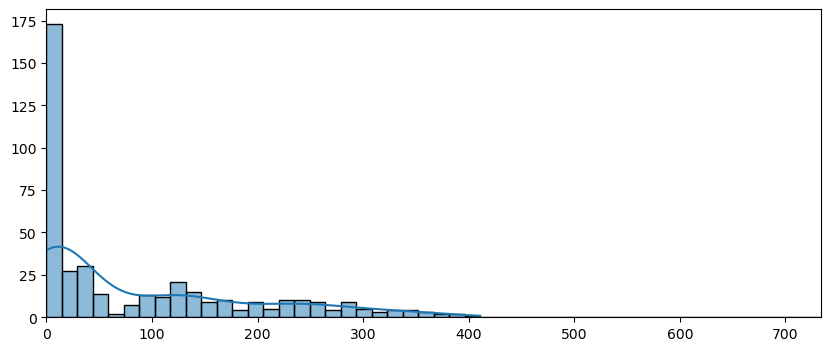

In [25]:
def display_abundhist(ax, metag, species, *, ksize=21, n_bins=50, title=None, verbose=False, label_axes=True, ymax=None):
    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))

    isect_sigfile = f"../outputs.abundhist/{species}.x.{metag}.isect.sig.zip"
    isect_sig = list(sourmash.load_file_as_signatures(isect_sigfile, ksize=ksize))
    assert len(isect_sig) == 1
    isect_sig = isect_sig[0]
    abunds = isect_sig.minhash.hashes

    # track hashval abundanc distribution
    counts_d = collections.defaultdict(int)
    # track abundance distribution, too
    counter = collections.Counter()

    for hashval, abund in abunds.items():
        abund = abunds[hashval]
        counts_d[hashval] += abund
        counter[abund] += 1

    all_counts = list(counts_d.values())
    counts_dist = list(counter.items())
    sum_hist = sum(counter.values())
    max_range = max(counter.values())
    min_range = 0

    # find count that covers 95% of distribution.
    sofar = 0
    for k, v in sorted(counts_dist):
        sofar += v
        if sofar >= 0.99*sum_hist:
            max_range = 2*k
            if verbose:
                print(f'setting default max_range to {max_range} (2x 99% of counts)')
            break
    
    sns.histplot(all_counts, ax=ax,
                     binrange=(min_range, max_range),
                     bins=n_bins, kde=True)

    #counts, bin_edges = np.histogram(all_counts,
    #                                 range=(min_range, max_range),
    #                                 bins=n_bins)
    #counts_bin3 = counts[2]

    if ymax:
        ax.set_ylim(top=ymax)
    #else:
    #    ax.set_ylim(top=counts_bin3)

    ax.set_xlim(min_range, max_range)

    if label_axes:
        ax.set_xlabel("k-mer abundance")
        ax.set_ylabel("N(k-mers at that abundance)")
    else:
        ax.set_ylabel("")

display_abundhist(None, 'SRR17241485', 's__Lactobacillus amylovorus', label_axes=False)

In [26]:
def plot_covhist_panel(species, metag_list, *, ymax=50, n_bins=50):
    fig, axes= plt.subplots(nrows=1, ncols=len(METAGS), figsize=(12, 4))
    fig.suptitle(species)
    
    for ax, metag in zip(axes, metag_list):
        depth_est, depth_all = get_cov_info(combo2_df, metag, species)
        #print(f'for {species} in {metag}, kmer depth: {depth_est:.1f} / mapping depth: {depth_all:.1f}')
        display_abundhist(ax, metag, species, label_axes=False, n_bins=n_bins, ymax=ymax)
        ax.set_title(metag)
    
        _, ymax = ax.get_ylim()
        ax.axvline(x=depth_est, color='red', linestyle='--')
        ax.axvline(x=depth_all, color='green', linestyle='--')

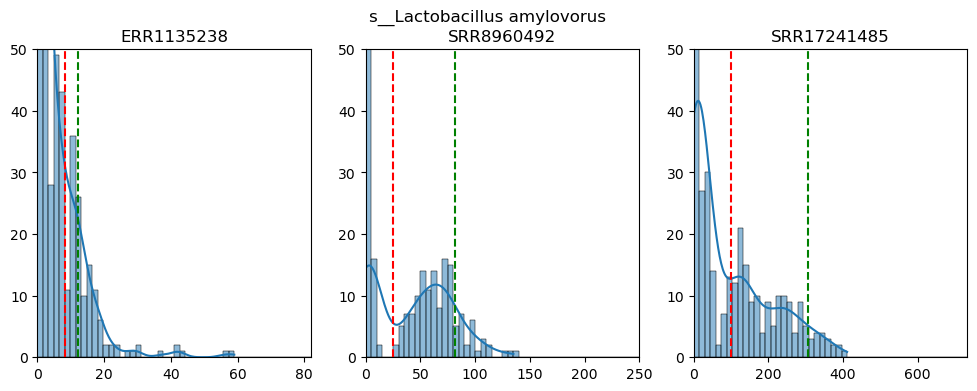

In [27]:
SS='s__Lactobacillus amylovorus'
METAGS=['ERR1135238', 'SRR8960492', 'SRR17241485']
plot_covhist_panel(SS, METAGS)

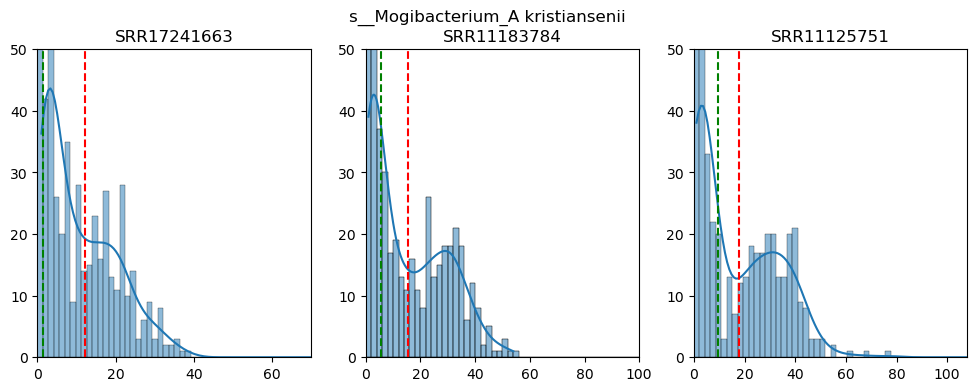

In [28]:
SS='s__Mogibacterium_A kristiansenii'

METAGS=[#'SRR14812372',
# 'SRR5240744',
 'SRR17241663',
# 'SRR8960625',
# 'SRR12795793',
 'SRR11183784',
# 'SRR17241609',
# 'SRR8960444',
 'SRR11125751',
# 'SRR8960379'
       ]

plot_covhist_panel(SS, METAGS)

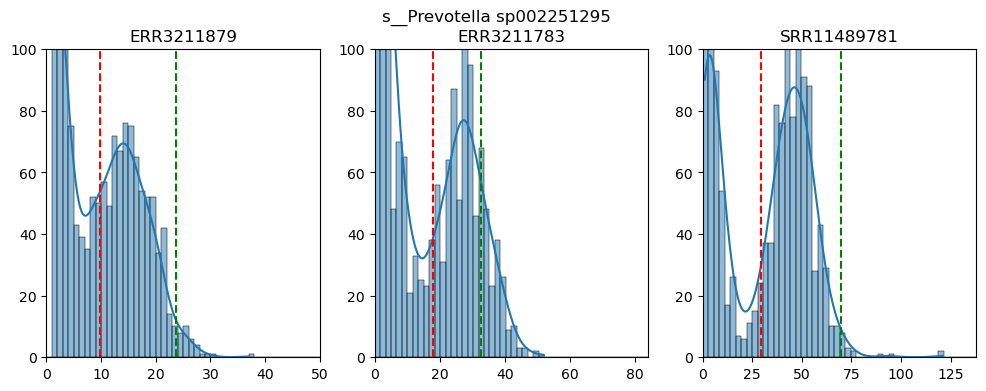

In [29]:
SS='s__Prevotella sp002251295'

METAGS=[
 #'SRR8960491',
 #'SRR5241534',
 #'ERR1135213',
 #'ERR3211839',
 'ERR3211879',
 #'ERR3211876',
 #'SRR14369134',
 'ERR3211783',
 #'SRR14369306',
 'SRR11489781']

plot_covhist_panel(SS, METAGS, ymax=100)

In [30]:
combo2_df['species'].unique()

species
str
"""s__Phascolarctobacterium_A suc…"
"""s__Prevotella sp002251295"""
"""s__Cryptobacteroides sp9005469…"
"""s__Mogibacterium_A kristiansen…"
"""s__Lactobacillus amylovorus"""
"""s__Sodaliphilus sp004557565"""


In [31]:
SS='s__Prevotella sp000434975'

METAGS = [
#    'SRR8960379',
#   'SRR8960101',
#   'SRR14812375',
   'ERR3211876',
#   'SRR14812372',
#   'ERR1135303',
   'SRR11489769',
#   'ERR3211839',
   'ERR8314767',
#   'ERR1135349'
]

#plot_covhist_panel(SS, METAGS, ymax=100)

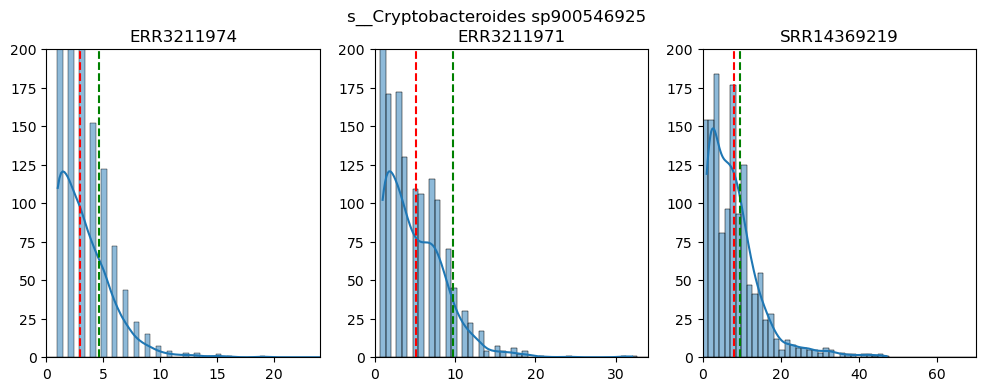

In [32]:
SS='s__Cryptobacteroides sp900546925'

METAGS = [#'SRR17241596',
                                          #'ERR3211812',
                                          'ERR3211974',
                                          #'ERR8314767',
                                          #'ERR8314788',
                                          'ERR3211971',
                                          #'SRR10209683',
                                          #'SRR11551383',
                                          'SRR14369219',
                                          #'SRR17241485'
         ]

plot_covhist_panel(SS, METAGS, ymax=200)

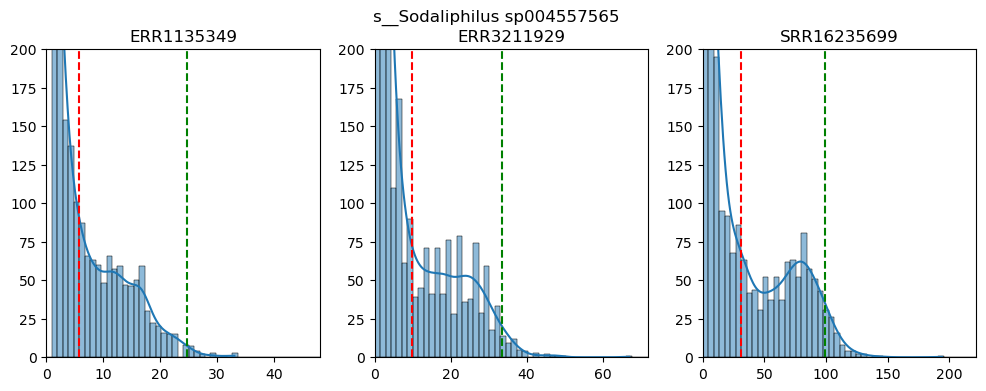

In [33]:
SS='s__Sodaliphilus sp004557565'

METAGS = [#'SRR11125534',
                                     #'SRR11805642',
                                     #'ERR8314743',
                                     'ERR1135349',
                                     #'ERR3211891',
                                     #'ERR8314788',
                                     'ERR3211929',
                                     #'ERR1135303',
                                     #'SRR10209683',
                                     'SRR16235699']

plot_covhist_panel(SS, METAGS, ymax=200)

TODO -
- look at gene-gene correlations systematically; plot, summarize?
- do more species
- pick specific anchor genes, and maybe remove others? or, indicate anchors in CSV.